# Au [100] Absorptive-Potential Sensitivity Test

This notebook tests whether adding a physically motivated imaginary potential
increases disagreement between propagation methods.

Methods included:
- Fresnel multislice
- Angular spectrum multislice
- Full KG ODE (reference)

Absorptive model:
- Imaginary potential is proportional to local positive real potential,
  so attenuation is strongest near atomic columns.

In [13]:
%matplotlib inline

import os
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.05"


import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from matplotlib.colors import LogNorm

from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_kg_ode_full,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

print("Imports complete.")

Imports complete.


## Crystal, probe, and real potential

The setup follows the Au [100] verification style, but uses a convergent probe
and fixed target thickness for CBED-style comparison.

In [14]:
# --- Runtime mode ---
quick_run = True  # True keeps runtime manageable while staying closer to verification settings
n_cells_xy = (1, 1)
n_slices_per_cell = 128

# --- Physical parameters (closer to 01_axel_lubk_verification) ---
energy = 300e3
a_au = 4.076
target_n_cells_z = 15
thickness_cells_plot_max = 25
use_plane_wave = True
semiangle_mrad = 6.2  # Only used if use_plane_wave = False

unit_cell = bulk("Au", "fcc", a=a_au, cubic=True)
unit_cell.pbc = [True, True, True]

z_period = float(unit_cell.cell[2, 2])
n_cells_z = int(target_n_cells_z)
supercell = unit_cell * (*n_cells_xy, n_cells_z)

slice_dz = z_period / n_slices_per_cell
total_thickness = float(supercell.cell[2, 2])
n_total_slices = n_cells_z * n_slices_per_cell

potential_ref = abtem.Potential(
    supercell,
    gpts=(128, 128),
    slice_thickness=slice_dz,
    projection="finite",
    parametrization="lobato",
)
gpts = tuple(potential_ref.gpts)

if use_plane_wave:
    pw = abtem.PlaneWave(energy=energy)
    pw.grid.match(potential_ref)
    probe_array = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
    sampling = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))
    probe_label = "Plane wave"
else:
    probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle_mrad)
    probe.grid.match(potential_ref)
    probe_array = jnp.array(cupy.asnumpy(probe.build(lazy=False).array))
    sampling = (float(probe.grid.sampling[0]), float(probe.grid.sampling[1]))
    probe_label = f"CBED probe ({semiangle_mrad:.1f} mrad)"

fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

# Potential for the 15-cell eta sweep
pot_static = abtem.Potential(
    supercell,
    gpts=gpts,
    slice_thickness=slice_dz,
    projection="finite",
    parametrization="lobato",
)
pot_real = jnp.array(cupy.asnumpy(pot_static.build(lazy=False).array / slice_dz))

# One-cell potential reused for 0-25 cell beam-thickness sweep
pot_cell = abtem.Potential(
    unit_cell,
    gpts=gpts,
    slice_thickness=slice_dz,
    projection="finite",
    parametrization="lobato",
)
pot_real_cell = jnp.array(cupy.asnumpy(pot_cell.build(lazy=False).array / slice_dz))

del pot_static, pot_cell
cupy.get_default_memory_pool().free_all_blocks()

wavelength = energy2wavelength(energy)
print(f"Mode: {'quick' if quick_run else 'full'}")
print(f"Supercell: {n_cells_xy[0]}x{n_cells_xy[1]}x{n_cells_z}, atoms={len(supercell)}")
print(f"Probe: {probe_label}")
print(f"Grid: {gpts}, sampling=({sampling[0]:.4f}, {sampling[1]:.4f}) A")
print(f"Slices: {n_total_slices} total ({n_slices_per_cell}/cell), dz={slice_dz:.4f} A")
print(f"Thickness: {total_thickness:.1f} A ({n_cells_z} unit cells), lambda={wavelength:.4f} A")
print(f"Thickness-sweep extent: 0 to {thickness_cells_plot_max} unit cells")

Mode: quick
Supercell: 1x1x15, atoms=60
Probe: Plane wave
Grid: (128, 128), sampling=(0.0318, 0.0318) A
Slices: 1920 total (128/cell), dz=0.0318 A
Thickness: 61.1 A (15 unit cells), lambda=0.0197 A
Thickness-sweep extent: 0 to 25 unit cells


## Build complex potential with atomic-column attenuation

We use a phenomenological absorptive term:

$$V_\mathrm{complex} = V_\mathrm{real} + i s \eta \max(V_\mathrm{real}, 0)$$

where $\eta$ controls attenuation strength and $s$ is a sign chosen so the
wave intensity decreases (not amplifies).

In [15]:
def intensity_ratio(exit_wave, incident_wave):
    i_out = float(np.sum(np.abs(np.asarray(exit_wave)) ** 2))
    i_in = float(np.sum(np.abs(np.asarray(incident_wave)) ** 2))
    return i_out / (i_in + 1e-30)

def make_absorptive_potential(pot_real_in, eta, sign):
    atom_weight = jnp.clip(jnp.real(pot_real_in), a_min=0.0)
    return pot_real_in + 1j * sign * eta * atom_weight

def choose_absorption_sign(pot_real_in, eta_probe=1e-3, n_probe_slices=4):
    n_test = min(int(n_probe_slices), int(pot_real_in.shape[0]))
    p_short = pot_real_in[:n_test]
    scores = {}

    for sgn in (+1, -1):
        p_complex = make_absorptive_potential(p_short, eta_probe, sgn)
        ew, _, _ = simulate_fresnel_as(p_complex, probe_array, fk, slice_dz, energy)
        scores[sgn] = intensity_ratio(ew, probe_array)

    best_sign = min(scores, key=scores.get)
    return best_sign, scores

absorption_sign, trial_scores = choose_absorption_sign(pot_real, eta_probe=1e-3, n_probe_slices=4)
print(f"Sign trial intensity ratios: {trial_scores}")
print(f"Chosen sign for attenuation: {absorption_sign:+d}")

Sign trial intensity ratios: {1: 0.999984311694698, -1: 1.0000156954185377}
Chosen sign for attenuation: +1


## Sweep attenuation and compare methods

For each $\eta$, run Fresnel and Angular Spectrum against Full KG ODE reference
using the same complex potential stack.

In [16]:
eta_values = np.array([0.0, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1], dtype=float)

def dp_norm(ew):
    dp = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew)))) ** 2
    return dp / (dp.max() + 1e-30)

def rel_l2(a, b):
    aa = np.asarray(a)
    bb = np.asarray(b)
    return float(np.linalg.norm(aa - bb) / (np.linalg.norm(bb) + 1e-30))

rows = []
sample_outputs = {}

for eta in eta_values:
    pot_c = make_absorptive_potential(pot_real, eta, absorption_sign)

    t0 = perf_counter()
    ew_f, _, _ = simulate_fresnel_as(pot_c, probe_array, fk, slice_dz, energy)
    t_f = perf_counter() - t0

    t0 = perf_counter()
    ew_a, _, _ = simulate_fresnel_as(pot_c, probe_array, ak, slice_dz, energy)
    t_a = perf_counter() - t0

    t0 = perf_counter()
    ew_k, _, _, _ = simulate_kg_ode_full(
        pot_c,
        probe_array,
        slice_dz,
        energy,
        sampling,
        rtol=1e-8,
        atol=1e-10,
        save_wavefronts=False,
    )
    t_k = perf_counter() - t0

    dpf = dp_norm(ew_f)
    dpa = dp_norm(ew_a)
    dpk = dp_norm(ew_k)

    rows.append({
        "eta": float(eta),
        "I_ratio_Fresnel": intensity_ratio(ew_f, probe_array),
        "I_ratio_AS": intensity_ratio(ew_a, probe_array),
        "I_ratio_KG": intensity_ratio(ew_k, probe_array),
        "relL2_DP_Fresnel_vs_KG": rel_l2(dpf, dpk),
        "relL2_DP_AS_vs_KG": rel_l2(dpa, dpk),
        "time_Fresnel_s": float(t_f),
        "time_AS_s": float(t_a),
        "time_KG_s": float(t_k),
    })

    sample_outputs[float(eta)] = {
        "Fresnel": dpf,
        "Angular Spectrum": dpa,
        "KG ODE": dpk,
    }

print(f"Sweep complete for {len(eta_values)} attenuation strengths.")
print()
print(f"{'eta':>10} {'I_F':>10} {'I_AS':>10} {'I_KG':>10} {'L2(F,KG)':>12} {'L2(AS,KG)':>12}")
print('-' * 72)
for r in rows:
    print(
        f"{r['eta']:10.3e} {r['I_ratio_Fresnel']:10.4f} {r['I_ratio_AS']:10.4f} {r['I_ratio_KG']:10.4f} ",
        f"{r['relL2_DP_Fresnel_vs_KG']:12.4e} {r['relL2_DP_AS_vs_KG']:12.4e}"
    )

/homelocal/dl277493/.pyenv/versions/JaxGym/lib/python3.12/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


Sweep complete for 7 attenuation strengths.

       eta        I_F       I_AS       I_KG     L2(F,KG)    L2(AS,KG)
------------------------------------------------------------------------
 0.000e+00     1.0000     1.0000     1.0001    9.4914e-04   2.2261e-04
 3.000e-04     0.9990     0.9990     0.9992    9.4483e-04   2.2150e-04
 1.000e-03     0.9968     0.9968     0.9970    9.3489e-04   2.1894e-04
 3.000e-03     0.9906     0.9906     0.9907    9.0743e-04   2.1197e-04
 1.000e-02     0.9698     0.9699     0.9700    8.2157e-04   1.9151e-04
 3.000e-02     0.9177     0.9178     0.9180    6.4789e-04   1.6642e-04
 1.000e-01     0.7866     0.7867     0.7869    4.9615e-04   3.4708e-04


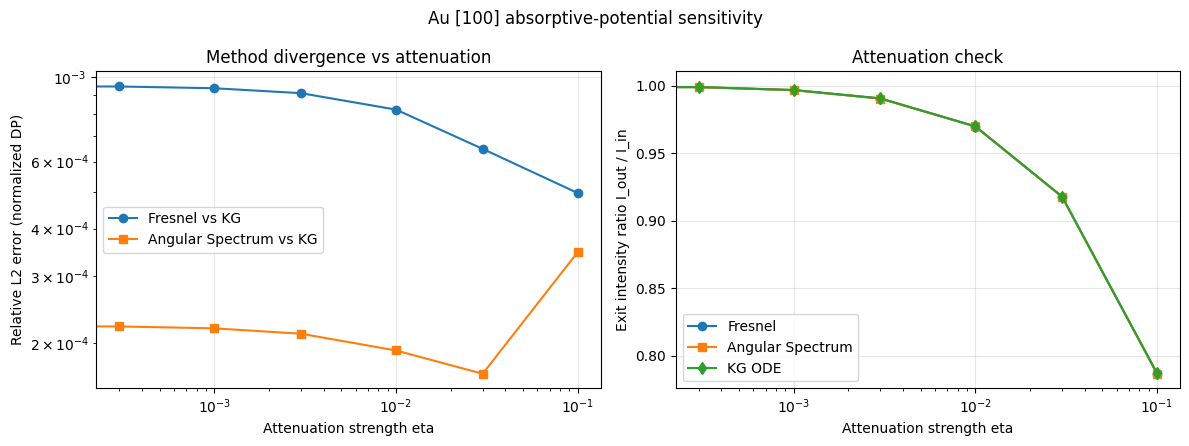

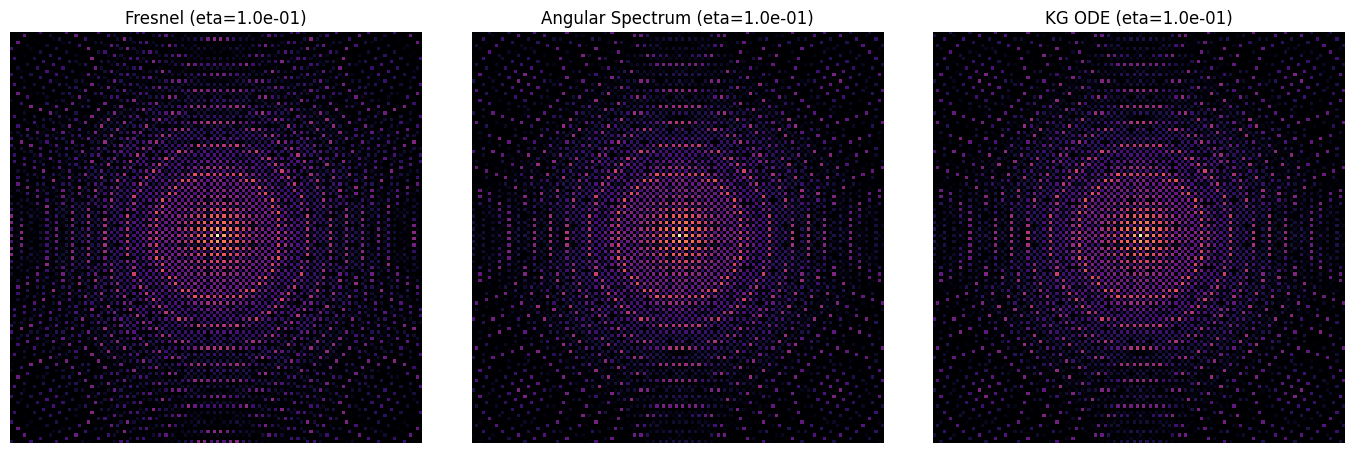

In [17]:
etas = np.array([r['eta'] for r in rows])
l2_f = np.array([r['relL2_DP_Fresnel_vs_KG'] for r in rows])
l2_a = np.array([r['relL2_DP_AS_vs_KG'] for r in rows])
ir_f = np.array([r['I_ratio_Fresnel'] for r in rows])
ir_a = np.array([r['I_ratio_AS'] for r in rows])
ir_k = np.array([r['I_ratio_KG'] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(etas, l2_f, 'o-', label='Fresnel vs KG')
axes[0].plot(etas, l2_a, 's-', label='Angular Spectrum vs KG')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Attenuation strength eta')
axes[0].set_ylabel('Relative L2 error (normalized DP)')
axes[0].set_title('Method divergence vs attenuation')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(etas, ir_f, 'o-', label='Fresnel')
axes[1].plot(etas, ir_a, 's-', label='Angular Spectrum')
axes[1].plot(etas, ir_k, 'd-', label='KG ODE')
axes[1].set_xscale('log')
axes[1].set_xlabel('Attenuation strength eta')
axes[1].set_ylabel('Exit intensity ratio I_out / I_in')
axes[1].set_title('Attenuation check')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle('Au [100] absorptive-potential sensitivity', fontsize=12)
plt.tight_layout()
plt.show()

eta_show = float(etas[-1])
fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
for j, name in enumerate(['Fresnel', 'Angular Spectrum', 'KG ODE']):
    img = sample_outputs[eta_show][name]
    ax[j].imshow(img, norm=LogNorm(vmin=1e-8, vmax=1.0), cmap='magma', origin='lower')
    ax[j].set_title(f"{name} (eta={eta_show:.1e})")
    ax[j].axis('off')
plt.tight_layout()
plt.show()

## Per-beam thickness sweep (0 to 25 unit cells)

> Styled after the verification notebook beam analysis for beams [0,0] and [0,28].

> We run this at two attenuation strengths: eta = 0 and eta = strong_eta.

In [18]:
def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    ny, nx = psi_xy.shape
    c = np.fft.fft2(psi_xy) / (nx * ny)
    if use_fftshift:
        c = np.fft.fftshift(c)
        cy, cx = ny // 2, nx // 2
        return np.abs(c[cy + k, cx + h])
    return np.abs(c[k % ny, h % nx])

n_cells_range = np.arange(0, thickness_cells_plot_max + 1, dtype=int)
strong_eta = float(eta_values[-1])
eta_for_beam_sweep = [0.0, strong_eta]
beam_curves = {}

for eta_case in eta_for_beam_sweep:
    pot_cell_c = make_absorptive_potential(pot_real_cell, eta_case, absorption_sign)

    w_f = probe_array
    w_a = probe_array
    w_k = probe_array
    phi_k = None

    curves = {
        "f_00": [], "f_028": [],
        "a_00": [], "a_028": [],
        "k_00": [], "k_028": [],
    }

    for icell in n_cells_range:
        if icell > 0:
            w_f, _, _ = simulate_fresnel_as(pot_cell_c, w_f, fk, slice_dz, energy)
            w_a, _, _ = simulate_fresnel_as(pot_cell_c, w_a, ak, slice_dz, energy)
            w_k, phi_k, _, _ = simulate_kg_ode_full(
                pot_cell_c,
                w_k,
                slice_dz,
                energy,
                sampling,
                initial_phi=phi_k,
                rtol=1e-8,
                atol=1e-10,
                save_wavefronts=False,
            )

        curves["f_00"].append(beam_amplitude_normalized(np.asarray(w_f), 0, 0))
        curves["f_028"].append(beam_amplitude_normalized(np.asarray(w_f), 0, 28))
        curves["a_00"].append(beam_amplitude_normalized(np.asarray(w_a), 0, 0))
        curves["a_028"].append(beam_amplitude_normalized(np.asarray(w_a), 0, 28))
        curves["k_00"].append(beam_amplitude_normalized(np.asarray(w_k), 0, 0))
        curves["k_028"].append(beam_amplitude_normalized(np.asarray(w_k), 0, 28))

    for key in curves:
        curves[key] = np.asarray(curves[key], dtype=float)
    beam_curves[eta_case] = curves

print(f"Beam-thickness sweep complete for eta values: {eta_for_beam_sweep}")

Beam-thickness sweep complete for eta values: [0.0, 0.1]


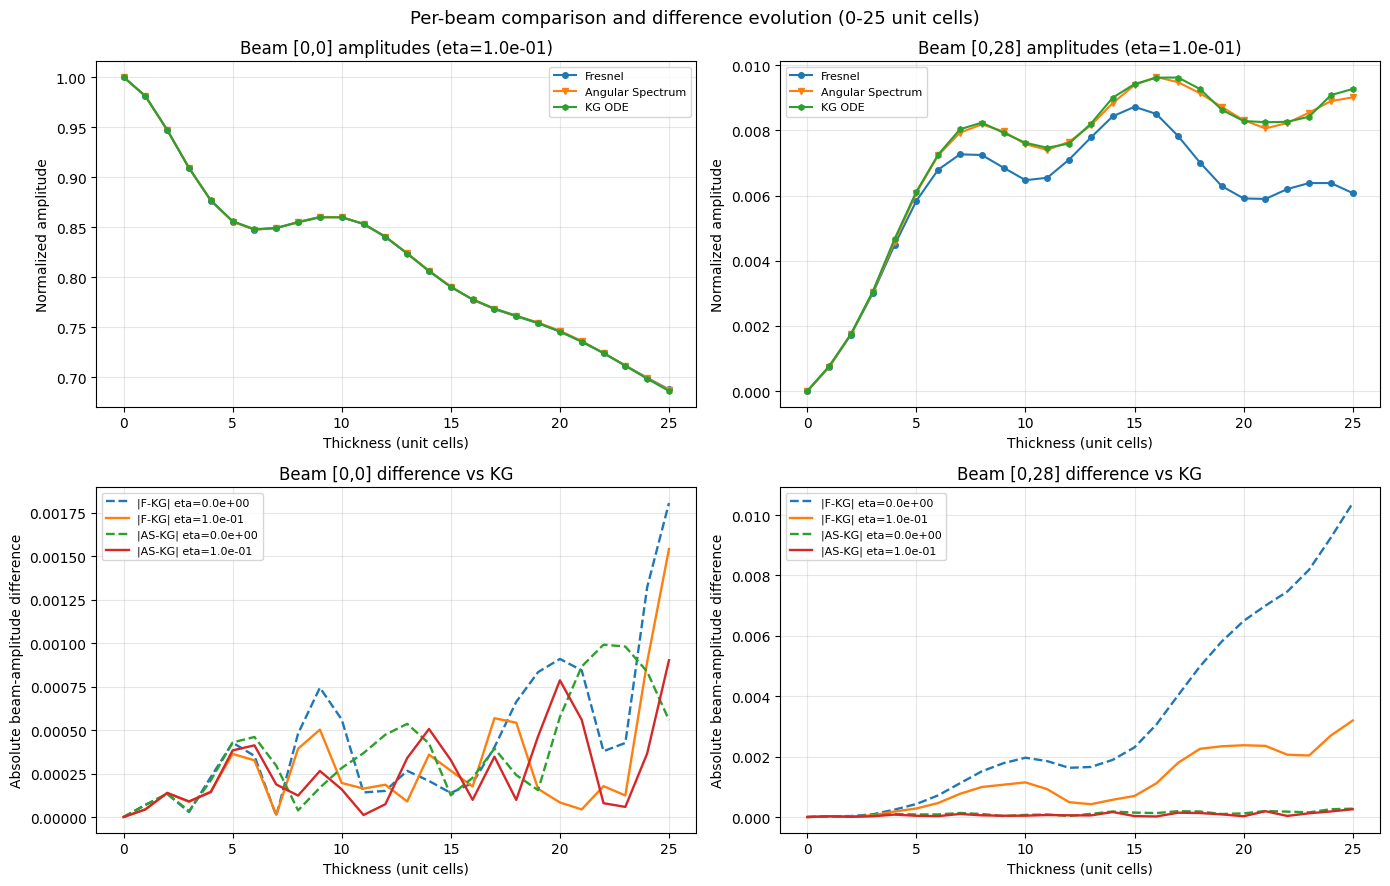

Final-thickness (25 cells) per-beam differences vs KG:
  Beam [0,0] |F-KG| eta=0: 1.8067e-03, eta=1.0e-01: 1.5418e-03
  Beam [0,0] |AS-KG| eta=0: 5.5798e-04, eta=1.0e-01: 9.0205e-04
  Beam [0,28] |F-KG| eta=0: 1.0399e-02, eta=1.0e-01: 3.1947e-03
  Beam [0,28] |AS-KG| eta=0: 2.7647e-04, eta=1.0e-01: 2.5732e-04


: 

In [ ]:
eta0 = float(eta_for_beam_sweep[0])
eta1 = float(eta_for_beam_sweep[1])
c0 = beam_curves[eta0]
c1 = beam_curves[eta1]

x = n_cells_range.astype(float)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Beam [0,0] amplitudes
axes[0, 0].plot(x, c1["f_00"], "o-", ms=4, label="Fresnel")
axes[0, 0].plot(x, c1["a_00"], "v-", ms=4, label="Angular Spectrum")
axes[0, 0].plot(x, c1["k_00"], "h-", ms=4, label="KG ODE")
axes[0, 0].set_title(f"Beam [0,0] amplitudes (eta={eta1:.1e})")
axes[0, 0].set_xlabel("Thickness (unit cells)")
axes[0, 0].set_ylabel("Normalized amplitude")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

# Beam [0,28] amplitudes
axes[0, 1].plot(x, c1["f_028"], "o-", ms=4, label="Fresnel")
axes[0, 1].plot(x, c1["a_028"], "v-", ms=4, label="Angular Spectrum")
axes[0, 1].plot(x, c1["k_028"], "h-", ms=4, label="KG ODE")
axes[0, 1].set_title(f"Beam [0,28] amplitudes (eta={eta1:.1e})")
axes[0, 1].set_xlabel("Thickness (unit cells)")
axes[0, 1].set_ylabel("Normalized amplitude")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

# Difference change with thickness: beam [0,0]
d00_f_eta0 = np.abs(c0["f_00"] - c0["k_00"])

d00_f_eta1 = np.abs(c1["f_00"] - c1["k_00"])

d00_a_eta0 = np.abs(c0["a_00"] - c0["k_00"])

d00_a_eta1 = np.abs(c1["a_00"] - c1["k_00"])

axes[1, 0].plot(x, d00_f_eta0, "--", lw=1.7, label=f"|F-KG| eta={eta0:.1e}")
axes[1, 0].plot(x, d00_f_eta1, "-", lw=1.7, label=f"|F-KG| eta={eta1:.1e}")
axes[1, 0].plot(x, d00_a_eta0, "--", lw=1.7, label=f"|AS-KG| eta={eta0:.1e}")
axes[1, 0].plot(x, d00_a_eta1, "-", lw=1.7, label=f"|AS-KG| eta={eta1:.1e}")
axes[1, 0].set_title("Beam [0,0] difference vs KG")
axes[1, 0].set_xlabel("Thickness (unit cells)")
axes[1, 0].set_ylabel("Absolute beam-amplitude difference")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

# Difference change with thickness: beam [0,28]
d028_f_eta0 = np.abs(c0["f_028"] - c0["k_028"])

d028_f_eta1 = np.abs(c1["f_028"] - c1["k_028"])

d028_a_eta0 = np.abs(c0["a_028"] - c0["k_028"])

d028_a_eta1 = np.abs(c1["a_028"] - c1["k_028"])

axes[1, 1].plot(x, d028_f_eta0, "--", lw=1.7, label=f"|F-KG| eta={eta0:.1e}")
axes[1, 1].plot(x, d028_f_eta1, "-", lw=1.7, label=f"|F-KG| eta={eta1:.1e}")
axes[1, 1].plot(x, d028_a_eta0, "--", lw=1.7, label=f"|AS-KG| eta={eta0:.1e}")
axes[1, 1].plot(x, d028_a_eta1, "-", lw=1.7, label=f"|AS-KG| eta={eta1:.1e}")
axes[1, 1].set_title("Beam [0,28] difference vs KG")
axes[1, 1].set_xlabel("Thickness (unit cells)")
axes[1, 1].set_ylabel("Absolute beam-amplitude difference")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

fig.suptitle("Per-beam comparison and difference evolution (0-25 unit cells)", fontsize=13)
plt.tight_layout()
plt.show()

print("Final-thickness (25 cells) per-beam differences vs KG:")
print(f"  Beam [0,0] |F-KG| eta=0: {d00_f_eta0[-1]:.4e}, eta={eta1:.1e}: {d00_f_eta1[-1]:.4e}")
print(f"  Beam [0,0] |AS-KG| eta=0: {d00_a_eta0[-1]:.4e}, eta={eta1:.1e}: {d00_a_eta1[-1]:.4e}")
print(f"  Beam [0,28] |F-KG| eta=0: {d028_f_eta0[-1]:.4e}, eta={eta1:.1e}: {d028_f_eta1[-1]:.4e}")
print(f"  Beam [0,28] |AS-KG| eta=0: {d028_a_eta0[-1]:.4e}, eta={eta1:.1e}: {d028_a_eta1[-1]:.4e}")

## Notes

- This attenuation model is phenomenological but physically motivated: absorption
  is localized where projected atomic potential is large.
- If your L2 curves rise with eta, absorption is amplifying method mismatch.
- If they fall, absorption is damping high-frequency differences.
- For a more physical inelastic model, the next step is parameterizing an explicit
  absorptive potential from literature (e.g., TDS-based effective imaginary potential).